# Off-target & rRNA features flag *bad* ASOs

Hypothesis: ASOs that carry **off-target burden — especially complementarity to ribosomal RNA**
— are rarely effective (sequestered / mis-targeted). These features don't pick the winners, but
they reliably flag losers (a negative filter).

Everything is measured **within cohort** (`custom_id`, which nests cell line and is essentially
single-chemistry), because Inhibition(%) is not comparable across experiments. Features are
oriented so **higher = more off-target burden**. Helpers in `_feat.py`; data is the full set
(all 131k oligos), cached to `data/raw_offtarget.parquet`.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import _feat as f
f.setup_style()
df = f.load()
print('oligos:', len(df), '| cohorts:', df[f.COHORT].nunique(), '| cell lines:', df.Cell_line.nunique())

oligos: 131711 | cohorts: 1701 | cell lines: 35


## 1 · High off-target ASOs vs their regular cohort-mates (real inhibition)
Within each experiment, take the **top 25% most off-target-burdened** ASOs ('high') and the rest
('regular'), and compare their **actual mean % inhibition**. Each dot is the average over cohorts
(so the experiment is controlled); the drop and the % of cohorts where high < regular are labelled.

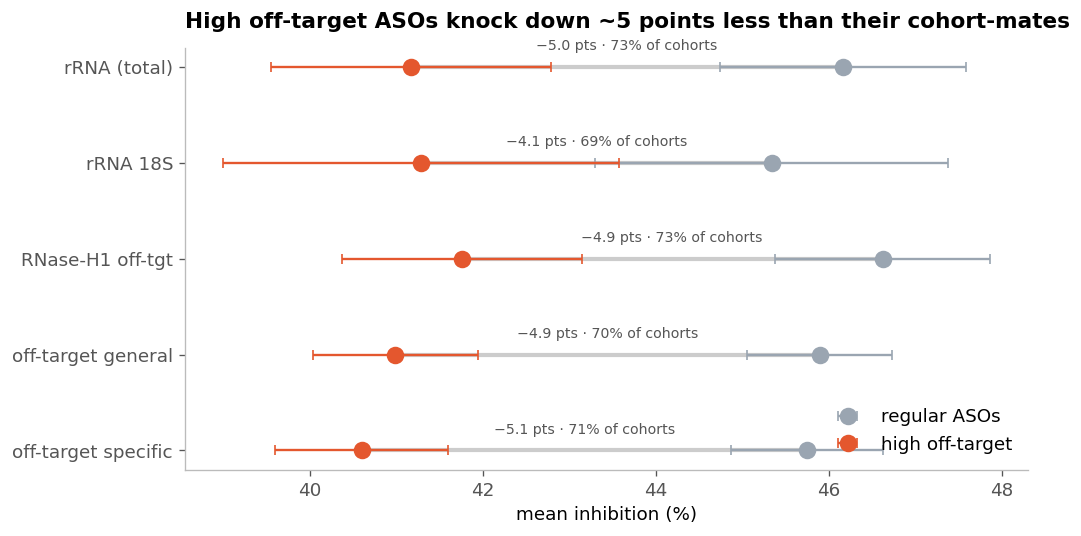

In [2]:
feats = ['rRNA (total)', 'rRNA 18S', 'RNase-H1 off-tgt', 'off-target general', 'off-target specific']
fig, ax = plt.subplots(figsize=(8.8, 4.6))
for i, name in enumerate(feats[::-1]):
    c = f.cohort_delta(df, name); reg, hi = c['reg'], c['high']; pct = 100*(c['delta'] < 0).mean()
    ax.plot([hi, reg], [i, i], color='#cccccc', lw=2.5, zorder=1)
    ax.errorbar(reg, i, xerr=c['reg_ci'], fmt='o', ms=9.5, color=f.GREY, ecolor=f.GREY,
                elinewidth=1.4, capsize=3, zorder=2, label='regular ASOs' if i == 0 else '')
    ax.errorbar(hi, i, xerr=c['high_ci'], fmt='o', ms=9.5, color=f.ACCENT, ecolor=f.ACCENT,
                elinewidth=1.4, capsize=3, zorder=2, label='high off-target' if i == 0 else '')
    ax.annotate(f'−{reg-hi:.1f} pts · {pct:.0f}% of cohorts', ((reg+hi)/2, i+0.18), ha='center', fontsize=8.5, color='#555')
ax.set_yticks(range(len(feats))); ax.set_yticklabels(feats[::-1])
ax.set_xlabel('mean inhibition (%)'); ax.set_title('High off-target ASOs knock down ~5 points less than their cohort-mates')
ax.legend(frameon=False, loc='lower right'); plt.tight_layout(); plt.show()

### What does "high" burden actually mean?
"High" = top-25% of burden *within each cohort*. These features are zero-inflated counts, so for
the rRNA / RNase-H1 ones most ASOs are exactly 0 and the high group is essentially *any* binding,
spanning many orders of magnitude (log1p x-axis). The `off-target general/specific` scores are
sign-flipped (higher = worse). Each strip is one ASO, coloured by its high/regular label; the
dashed line is the median per-cohort 'high' cutoff. The table reports, per feature, the % of ASOs
that are nonzero, that cutoff, and a typical high vs regular value.

feature                 %nonzero   high cutoff   typ. high  typ. regular


rRNA (total)               23.8%             0    1.22e+05             0


RNase-H1 off-tgt           27.7%             0    5.45e+04             0


off-target general         62.9%         0.975        2.64        0.0102


off-target specific        63.3%          1.29        3.29        0.0138


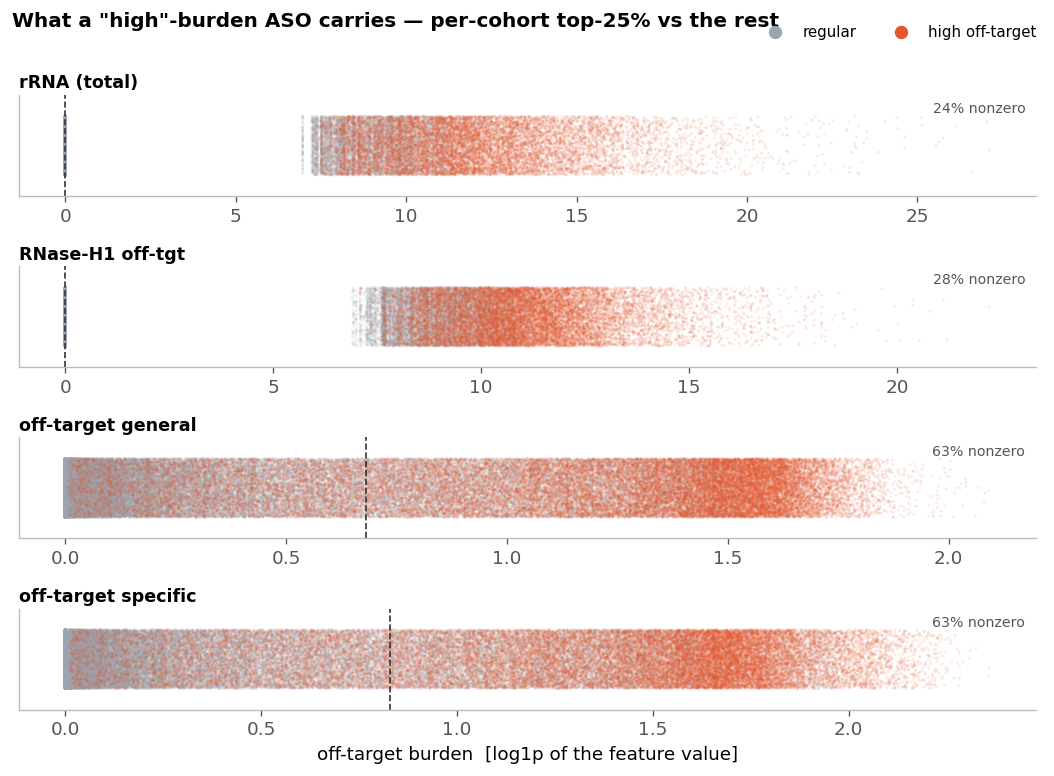

In [3]:
feats = ['rRNA (total)', 'RNase-H1 off-tgt', 'off-target general', 'off-target specific']
rng = np.random.default_rng(0)
fig, ax = plt.subplots(len(feats), 1, figsize=(8.8, 6.4), sharex=False)
print(f"{'feature':22s}{'%nonzero':>10s}{'high cutoff':>14s}{'typ. high':>12s}{'typ. regular':>14s}")
for a, name in zip(ax, feats):
    hi, reg = f.burden_values(df, name); s = f.burden_summary(df, name)
    for vals, col, lab in [(reg, f.GREY, 'regular'), (hi, f.ACCENT, 'high')]:
        x = np.log1p(vals)
        a.scatter(x, rng.uniform(-.35, .35, len(x)), s=3, color=col, alpha=.12, edgecolors='none',
                  rasterized=True, label=lab)
    a.axvline(np.log1p(s['cutoff']), color='#333', ls='--', lw=1)
    a.set_yticks([]); a.set_ylim(-.6, .6)
    a.set_title(name, fontsize=10.5, pad=4)
    a.annotate(f"{s['pct_nonzero']:.0f}% nonzero", (.99, .82), xycoords='axes fraction',
               ha='right', fontsize=8.5, color='#555')
    print(f"{name:22s}{s['pct_nonzero']:9.1f}%{s['cutoff']:14.3g}{s['high']:12.3g}{s['reg']:14.3g}")
h = [plt.Line2D([], [], marker='o', ls='', ms=7, color=c) for c in (f.GREY, f.ACCENT)]
fig.legend(h, ['regular', 'high off-target'], frameon=False, fontsize=9, ncol=2,
           loc='upper right', bbox_to_anchor=(0.995, 1.005))
ax[-1].set_xlabel('off-target burden  [log1p of the feature value]')
fig.suptitle('What a "high"-burden ASO carries — per-cohort top-25% vs the rest',
             x=.012, ha='left', fontweight='bold', fontsize=12, y=1.005)
plt.tight_layout(); plt.show()

### Is the ~5-point drop within noise?
For each feature, every cohort gives one **delta = high_mean − reg_mean** (in real % inhibition).
Left: the distribution of those per-cohort deltas, with 0 marked and the mean ± 95% CI (t-based)
overlaid — the mass sits clearly left of 0. Right: the mean delta ± 95% CI per feature, annotated
with the paired **Wilcoxon** p (high vs regular across cohorts). The drop is small but extremely
robust: every CI excludes 0 by a wide margin.

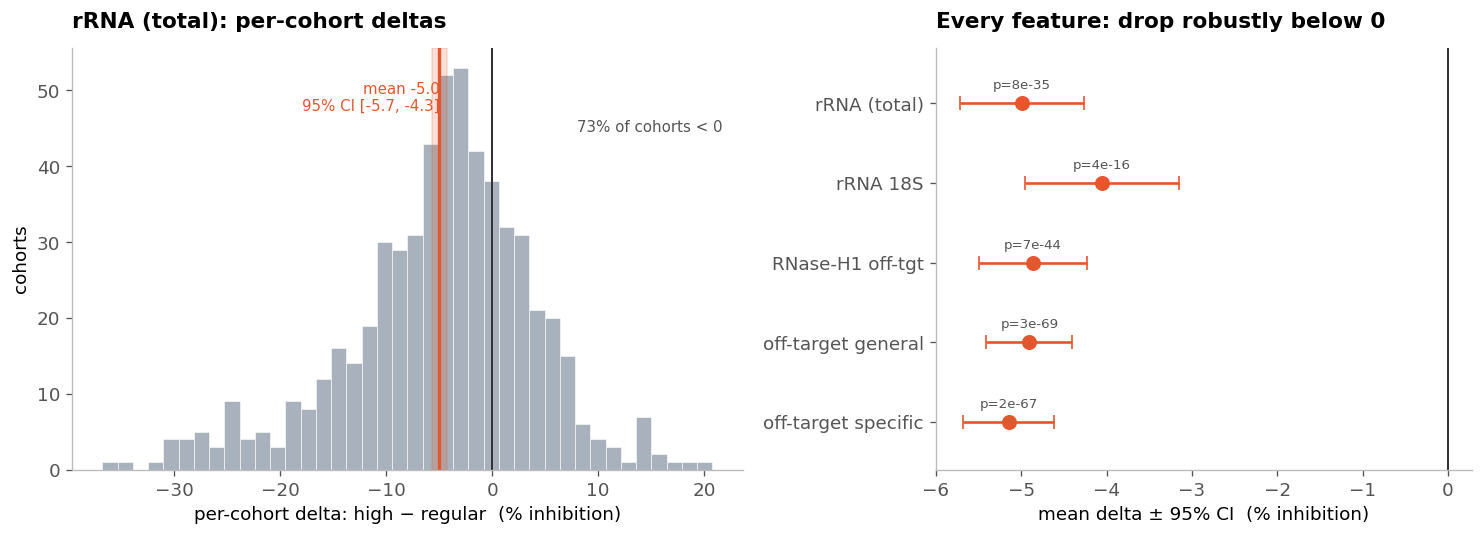

feature                 n_coh   mean delta      95% CI          wilcoxon p
rRNA (total)             581     -4.99   [-5.72, -4.26]   7.94e-35
rRNA 18S                 295     -4.05   [-4.96, -3.15]   3.54e-16
RNase-H1 off-tgt         715     -4.86   [-5.49, -4.23]   6.96e-44
off-target general      1493     -4.90   [-5.41, -4.40]   2.87e-69
off-target specific     1374     -5.15   [-5.68, -4.62]   1.62e-67


In [4]:
feats = ['rRNA (total)', 'rRNA 18S', 'RNase-H1 off-tgt', 'off-target general', 'off-target specific']
res = {name: f.cohort_delta(df, name) for name in feats}
fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.6), gridspec_kw={'width_ratios': [1.25, 1]})

# left: distribution of per-cohort deltas for the headline rRNA feature
c = res['rRNA (total)']; delta = c['delta']
ax[0].hist(delta, bins=40, color=f.GREY, alpha=.85, edgecolor='white', linewidth=.4)
ax[0].axvline(0, color='#333', lw=1.2)
ax[0].axvspan(c['mean']-c['ci'], c['mean']+c['ci'], color=f.ACCENT, alpha=.18)
ax[0].axvline(c['mean'], color=f.ACCENT, lw=2)
ax[0].annotate(f"mean {c['mean']:+.1f}\n95% CI [{c['mean']-c['ci']:+.1f}, {c['mean']+c['ci']:+.1f}]",
               (c['mean'], ax[0].get_ylim()[1]*.92), ha='right', va='top', fontsize=9, color=f.ACCENT)
ax[0].annotate(f"{100*(delta<0).mean():.0f}% of cohorts < 0", (.97, .80), xycoords='axes fraction',
               ha='right', fontsize=9, color='#555')
ax[0].set_xlabel('per-cohort delta: high − regular  (% inhibition)')
ax[0].set_ylabel('cohorts'); ax[0].set_title('rRNA (total): per-cohort deltas')

# right: mean delta +/- 95% CI per feature, with Wilcoxon p
y = np.arange(len(feats))[::-1]
ax[1].axvline(0, color='#333', lw=1.2)
for yi, name in zip(y, feats):
    r = res[name]
    ax[1].errorbar(r['mean'], yi, xerr=r['ci'], fmt='o', ms=8, color=f.ACCENT,
                   ecolor=f.ACCENT, elinewidth=1.6, capsize=4)
    ax[1].annotate(f"p={r['p']:.0e}", (r['mean'], yi+0.18), ha='center', fontsize=8, color='#555')
ax[1].set_yticks(y); ax[1].set_yticklabels(feats); ax[1].set_ylim(-0.6, len(feats)-0.3)
ax[1].set_xlabel('mean delta ± 95% CI  (% inhibition)')
ax[1].set_title('Every feature: drop robustly below 0')
plt.tight_layout(); plt.show()

print('feature                 n_coh   mean delta      95% CI          wilcoxon p')
for name in feats:
    r = res[name]
    print(f"{name:22s}{r['n']:6d}  {r['mean']:+8.2f}   [{r['mean']-r['ci']:+.2f}, {r['mean']+r['ci']:+.2f}]   {r['p']:.2e}")

## 2 · Per-cohort view — high-rRNA ASOs underperform almost everywhere
Each dot is one experiment: x = mean inhibition of its regular ASOs, y = mean inhibition of its high-rRNA ASOs. Below the diagonal = high-rRNA worse. Dot size = cohort size.

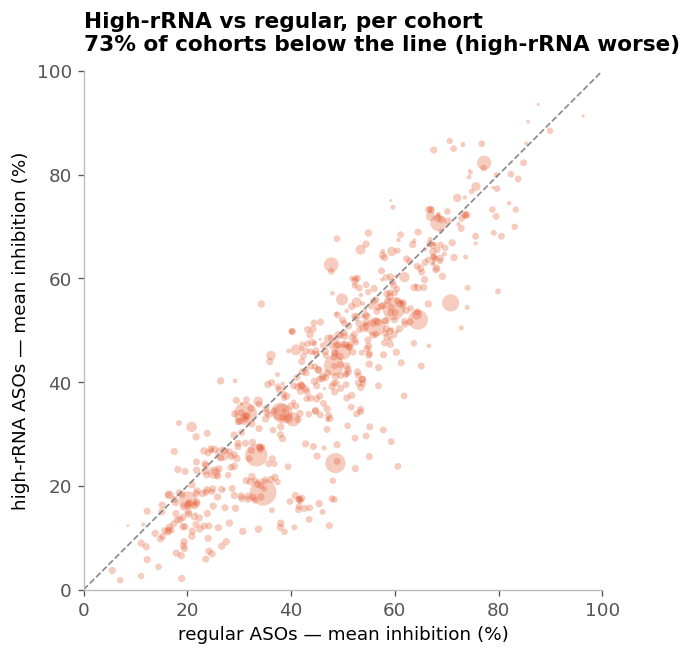

In [5]:
d = f.high_vs_regular(df, 'rRNA (total)')
fig, ax = plt.subplots(figsize=(5.6, 5.6))
ax.scatter(d.reg, d.high, s=d.n/4, alpha=.30, color=f.ACCENT, edgecolors='none')
ax.plot([0, 100], [0, 100], color='#888', ls='--', lw=1)
ax.set_xlim(0, 100); ax.set_ylim(0, 100); ax.set_aspect('equal')
ax.set_xlabel('regular ASOs — mean inhibition (%)'); ax.set_ylabel('high-rRNA ASOs — mean inhibition (%)')
ax.set_title(f'High-rRNA vs regular, per cohort\n{100*(d.high<d.reg).mean():.0f}% of cohorts below the line (high-rRNA worse)')
plt.tight_layout(); plt.show()

## 3 · The gradient is dose-dependent (rRNA / RNase-H1)
More rRNA binding → progressively worse, as within-cohort residual inhibition (oligo minus its cohort mean).

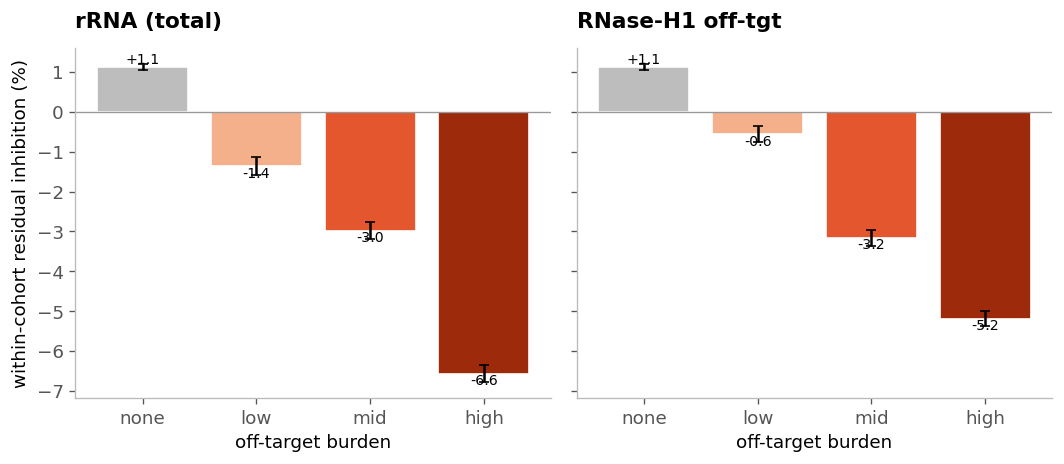

In [6]:
feats = ['rRNA (total)', 'RNase-H1 off-tgt']
fig, ax = plt.subplots(1, 2, figsize=(9, 4), sharey=True)
for a, name in zip(ax, feats):
    t = f.resid_by_bin(df, name)
    a.bar(range(len(t)), t['mean'], yerr=t['se'], color=f.SEQ[:len(t)], capsize=3, edgecolor='white')
    a.set_xticks(range(len(t))); a.set_xticklabels(t.index)
    a.axhline(0, color='#999', lw=.8); a.set_title(name); a.set_xlabel('off-target burden')
    for i, m in enumerate(t['mean']):
        a.annotate(f'{m:+.1f}', (i, m), ha='center', va='bottom' if m >= 0 else 'top', fontsize=8.5)
ax[0].set_ylabel('within-cohort residual inhibition (%)')
plt.tight_layout(); plt.show()

## 2 · Strong ASOs are depleted of off-target hits
Within each cohort, label the top-25%-inhibition oligos *strong* and bottom-25% *weak*; bars show the fraction carrying any of that off-target burden.

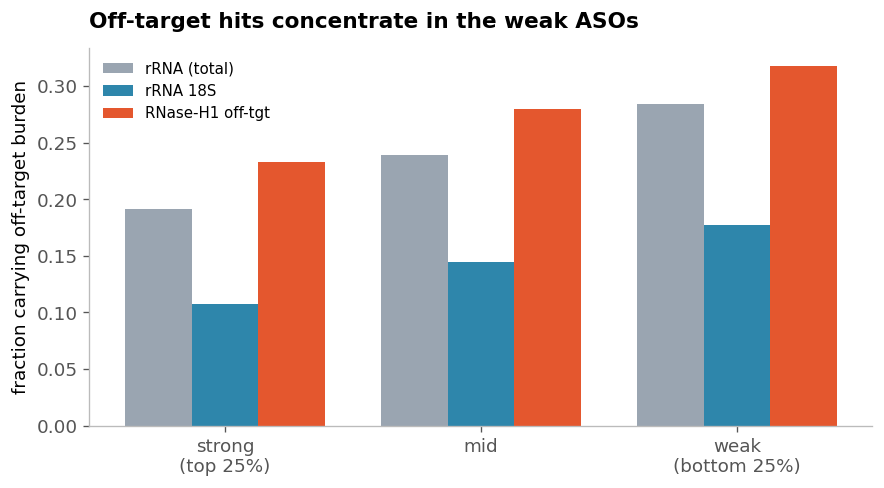

In [7]:
cats = ['strong', 'mid', 'weak']; feats = ['rRNA (total)', 'rRNA 18S', 'RNase-H1 off-tgt']
x = np.arange(len(cats)); w = 0.26
fig, ax = plt.subplots(figsize=(7.5, 4.2))
for i, name in enumerate(feats):
    d = f.strong_weak_depletion(df, name)
    ax.bar(x + (i-1)*w, [d[c] for c in cats], w, label=name, color=[f.GREY, f.BLUE, f.ACCENT][i])
ax.set_xticks(x); ax.set_xticklabels(['strong\n(top 25%)', 'mid', 'weak\n(bottom 25%)'])
ax.set_ylabel('fraction carrying off-target burden'); ax.set_title('Off-target hits concentrate in the weak ASOs')
ax.legend(frameon=False, fontsize=9); plt.tight_layout(); plt.show()

## 3 · Consistent *within* cohorts — not a cross-experiment artifact
Distribution over cohorts of Spearman(burden, inhibition). Centred left of 0 = burden flags worse ASOs in most experiments.

/tmp/claude-1000/ipykernel_2456914/3100153284.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, vert=False, labels=feats, showmeans=True, patch_artist=True,


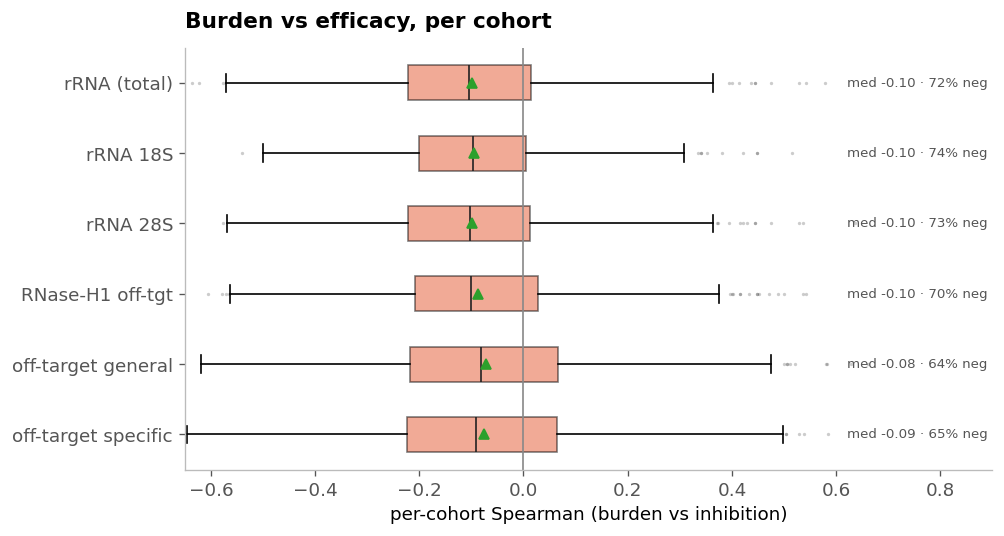

In [8]:
feats = list(f.BURDEN)
data = [f.per_cohort_corr(df, n) for n in feats]
fig, ax = plt.subplots(figsize=(8.5, 4.6))
bp = ax.boxplot(data, vert=False, labels=feats, showmeans=True, patch_artist=True,
                medianprops=dict(color='#222'), flierprops=dict(marker='.', ms=2, alpha=.2))
for b in bp['boxes']: b.set_facecolor(f.ACCENT); b.set_alpha(.5)
ax.axvline(0, color='#888', lw=1)
for i, d in enumerate(data):
    ax.text(0.62, i+1, f'med {np.median(d):+.2f} · {100*np.mean(d<0):.0f}% neg', va='center', fontsize=8, color='#555')
ax.set_xlim(-0.65, 0.9); ax.invert_yaxis(); ax.set_xlabel('per-cohort Spearman (burden vs inhibition)')
ax.set_title('Burden vs efficacy, per cohort'); plt.tight_layout(); plt.show()

## 4 · Holds across chemistry & cell line
The rRNA effect is present in both chemistries (stronger in cEt) and across the major cell lines.

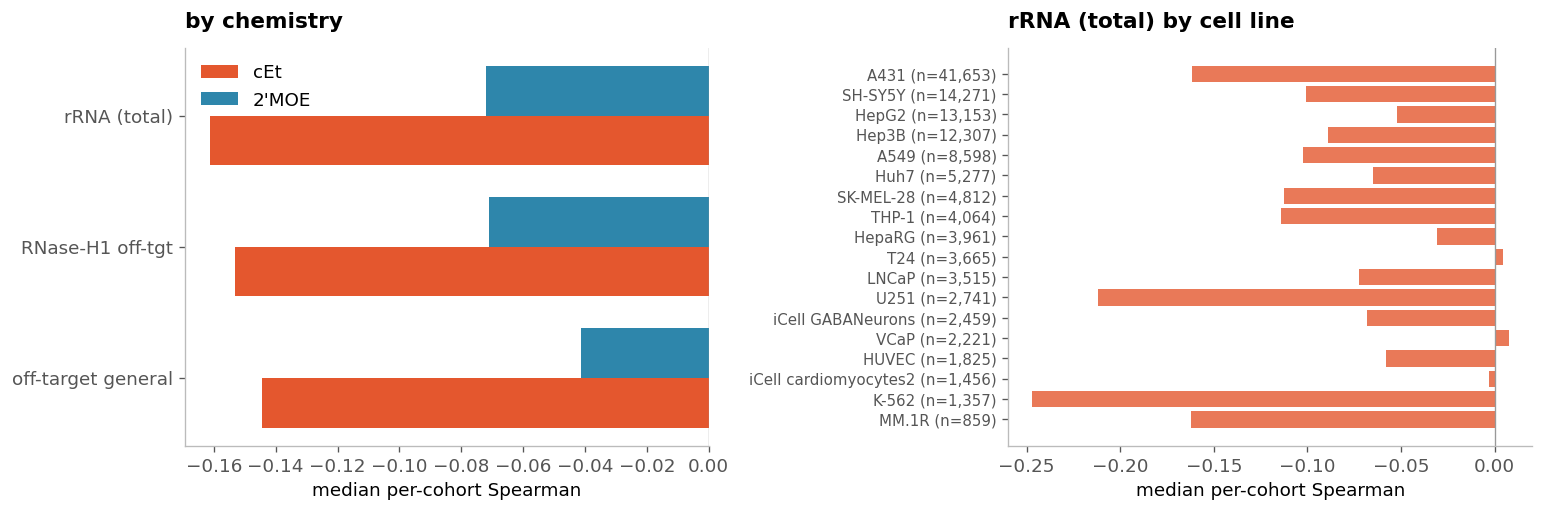

In [9]:
name = 'rRNA (total)'
fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))
# by chemistry, two features
chems = ['cEt', "2'MOE"]; show = ['rRNA (total)', 'RNase-H1 off-tgt', 'off-target general']
xx = np.arange(len(show)); w = 0.38
for j, ch in enumerate(chems):
    sub = df[df.chem == ch]
    meds = [np.median(f.per_cohort_corr(sub, s)) for s in show]
    ax[0].barh(xx + (0.5-j)*w, meds, w, label=ch, color=[f.ACCENT, f.BLUE][j])
ax[0].set_yticks(xx); ax[0].set_yticklabels(show); ax[0].invert_yaxis(); ax[0].axvline(0, color='#999', lw=.8)
ax[0].set_xlabel('median per-cohort Spearman'); ax[0].set_title('by chemistry'); ax[0].legend(frameon=False)
# by cell line (rRNA total), sorted by n
nc = df.groupby('Cell_line').size().sort_values(ascending=False)
cl = [c for c in nc.index if (df.Cell_line == c).sum() >= 800]
meds = [(c, np.median(f.per_cohort_corr(df[df.Cell_line == c], name)), int((df.Cell_line == c).sum())) for c in cl]
meds = [m for m in meds if np.isfinite(m[1])]
y = np.arange(len(meds))[::-1]
ax[1].barh(y, [m[1] for m in meds], color=f.ACCENT, alpha=.8)
ax[1].set_yticks(y); ax[1].set_yticklabels([f'{m[0]} (n={m[2]:,})' for m in meds], fontsize=9)
ax[1].axvline(0, color='#999', lw=.8); ax[1].set_xlabel('median per-cohort Spearman')
ax[1].set_title(f'{name} by cell line'); plt.tight_layout(); plt.show()